# Melanoma Pipeline — YOLO (detekcja) + U-Net (segmentacja) + EfficientNet-B4 (klasyfikacja)

**Wersja 2** — poprawki po code review:
- Wybor bboxa z YOLO po najwyzszym `conf` (zamiast zawsze pierwszego z listy)
- Spojne przenoszenie modeli i tensorow na `device` (przygotowane pod GPU / przyszly ONNX/TensorRT)

Klasyfikator: EfficientNet-B4 (recall 93.9% na 505 zdjeciach, vs 84.4% dla B0).

Zmiany wzgledem poprzedniej wersji (B0 -> B4):
- Klasyfikator: `timm` zamiast `torchvision.models` (B4 byl trenowany przez timm)
- Wejscie klasyfikatora: 380x380 zamiast 224x224 (rozmiar dopasowany do B4)
- Wyjscie: 1 neuron + sigmoid (binarne) zamiast 2 neuronow + softmax
- Reszta pipeline'u (YOLO detekcja, U-Net segmentacja) bez zmian


In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
import segmentation_models_pytorch as smp
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import timm
import os

# Transform dla KLASYFIKATORA B4 -- 380x380, zgodnie z trenowanym modelem
transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# device wykrywany automatycznie -- jesli jest GPU, uzyjemy go konsekwentnie
# we wszystkich modelach i tensorach ponizej (wczesniej bylo to tylko
# zdefiniowane, ale nigdzie faktycznie uzywane -- dzialalo bo defaultowo
# wszystko bylo na CPU; teraz pipeline jest gotowy pod GPU / TensorRT)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cpu


## Wczytanie modeli

Sciezka do klasyfikatora zmieniona na nowy plik B4. Podmien nazwe/sciezke jesli
u Ciebie plik lezy gdzie indziej (np. `../models/efficientnet_b4_melanoma_final.pt`).


In [2]:
# Klasyfikator -- EfficientNet-B4 (timm), binarny (1 neuron + sigmoid)
classifier = timm.create_model('efficientnet_b4', pretrained=False, num_classes=1)
classifier.load_state_dict(torch.load('../models/efficientnet_b4_melanoma_final.pt', map_location=device))
classifier.to(device)
classifier.eval()

# U-Net -- bez zmian w architekturze, teraz jawnie na device
unet = smp.Unet(
    encoder_name='efficientnet-b0',
    encoder_weights=None,
    in_channels=3,
    classes=1,
)
unet.load_state_dict(torch.load('../models/unet_melanoma.pth', map_location=device))
unet.to(device)
unet.eval()

# YOLO -- ultralytics samo zarzadza device wewnetrznie przy .predict(),
# ale mozemy jawnie wskazac, ktorego uzyc
yolo_model = YOLO('../models/yolo_best.pt')
yolo_model.to(device)

print(f'Wszystkie modele wczytane na {device}! (klasyfikator: EfficientNet-B4)')


Wszystkie modele wczytane na cpu! (klasyfikator: EfficientNet-B4)


## Funkcja pomocnicza -- predykcja klasyfikatora

Wydzielona osobno, bo teraz logika jest inna niz przy B0 (sigmoid zamiast softmax,
jedna wartosc prawdopodobienstwa zamiast dwoch).


In [3]:
def classify(img_pil, threshold=0.5):
    """Zwraca (etykieta, pewnosc) dla podanego obrazu PIL, uzywajac klasyfikatora B4."""
    img_tensor = transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        logit = classifier(img_tensor)
        prob_malignant = torch.sigmoid(logit).item()

    if prob_malignant >= threshold:
        return 'malignant', prob_malignant
    else:
        return 'benign', 1 - prob_malignant


## Pelny pipeline: YOLO -> U-Net -> Klasyfikator (B4)

In [4]:
def run_pipeline(image_path):
    # 1. Wczytaj zdjecie
    img = Image.open(image_path).convert('RGB')

    # 2. YOLO -> znajdz zmiane
    yolo_results = yolo_model.predict(source=image_path, conf=0.25, save=False, verbose=False)
    boxes = yolo_results[0].boxes

    if len(boxes) == 0:
        print('YOLO: brak wykrytych zmian')
        return None, None

    # wybierz bbox z najwyzszym conf (nie zawsze pierwszy z listy = najpewniejszy)
    confs = boxes.conf.cpu().numpy()
    best_idx = int(confs.argmax())
    box = boxes[best_idx].xyxy[0].cpu().numpy()
    best_conf = float(confs[best_idx])
    x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])

    # 3. Wytnij zmiane z bbox
    cropped = img.crop((x1, y1, x2, y2))

    # 4. U-Net -> maska na wycietym fragmencie
    img_unet = torch.tensor(np.array(cropped.resize((256, 256)))).permute(2, 0, 1).float() / 255.0
    img_unet = img_unet.unsqueeze(0).to(device)

    with torch.no_grad():
        mask = torch.sigmoid(unet(img_unet))
        mask = (mask > 0.5).float().squeeze()

    mask_np = mask.cpu().numpy()

    # 5. Klasyfikator B4 na wycietym fragmencie
    predicted_label, confidence = classify(cropped)

    # 6. Wizualizacja
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    import cv2
    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)
    axes[0].imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'YOLO detection (conf={best_conf:.2f})')

    axes[1].imshow(cropped)
    axes[1].set_title('Cropped lesion')

    axes[2].imshow(mask_np, cmap='gray')
    axes[2].set_title('U-Net mask')

    axes[3].imshow(cropped)
    axes[3].set_title(f'{predicted_label} ({confidence:.2%})')

    plt.tight_layout()
    plt.show()

    return predicted_label, confidence


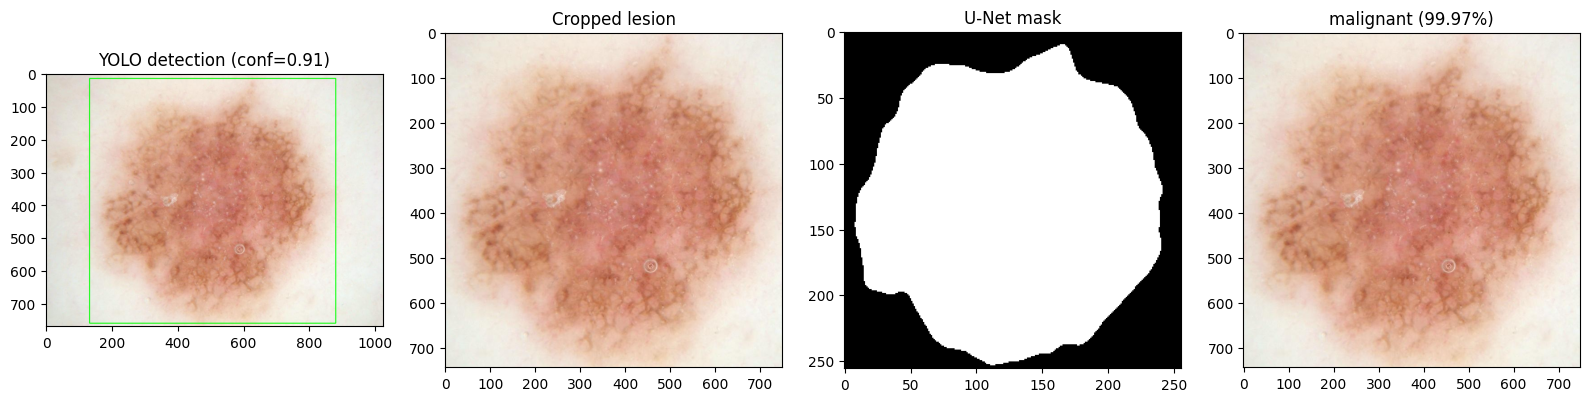

Wynik: malignant (99.97%)


In [9]:
# 1. Najpierw definiujesz ścieżkę do zmiennej
test_img_path = r'../test_image/ISIC_0012603.jpg'

# 2. Przekazujesz zmienną (BEZ dodatkowych apostrofów wokół niej)
label, confidence = run_pipeline(test_img_path)

if label is not None:
    print(f'Wynik: {label} ({confidence:.2%})')
else:
    print('Brak detekcji ze strony YOLO.')


Znaleziono 10 zdjec w folderze.



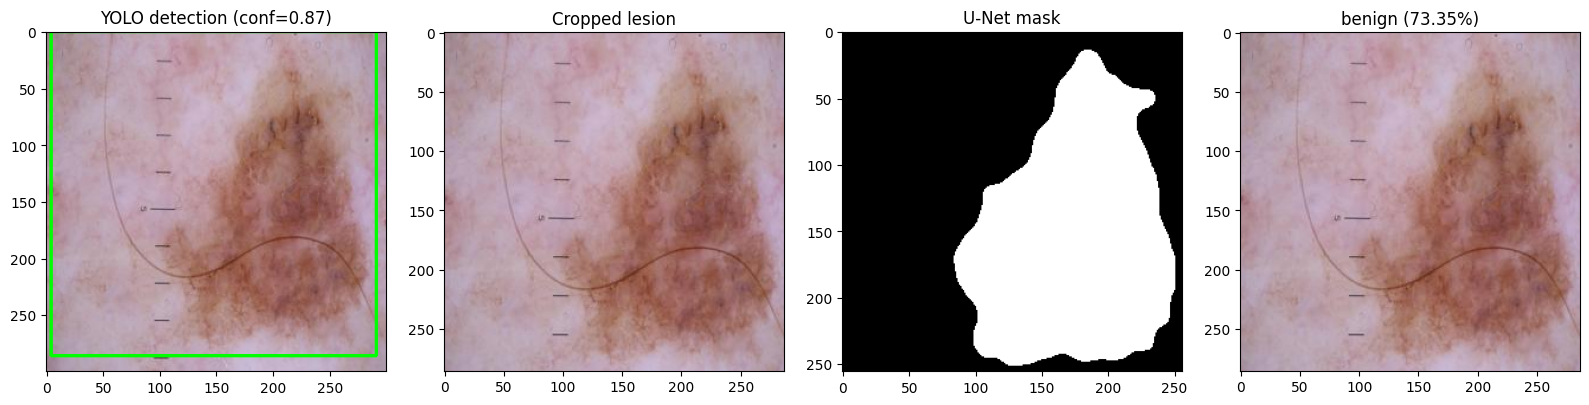

melanoma_10105.jpg: benign (73.35%)
YOLO: brak wykrytych zmian
melanoma_10106.jpg: Brak detekcji ze strony YOLO.


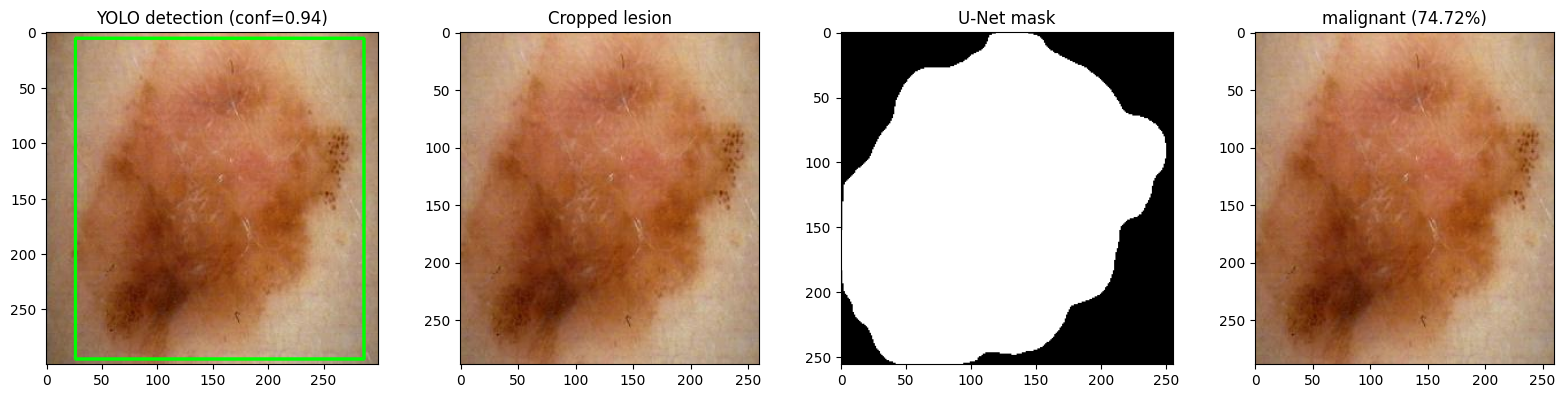

melanoma_10107.jpg: malignant (74.72%)


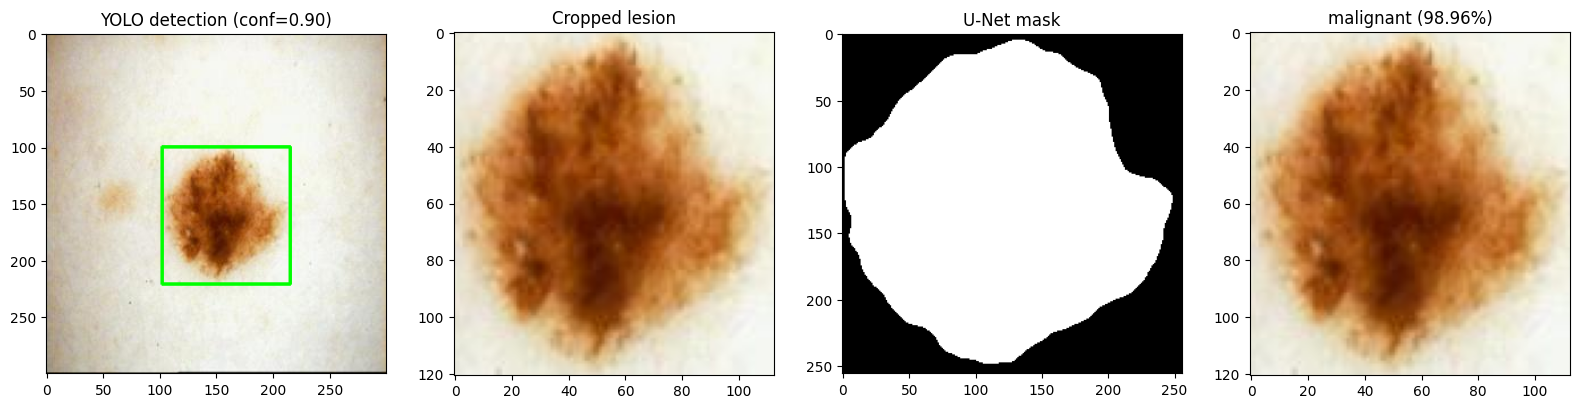

melanoma_10108.jpg: malignant (98.96%)


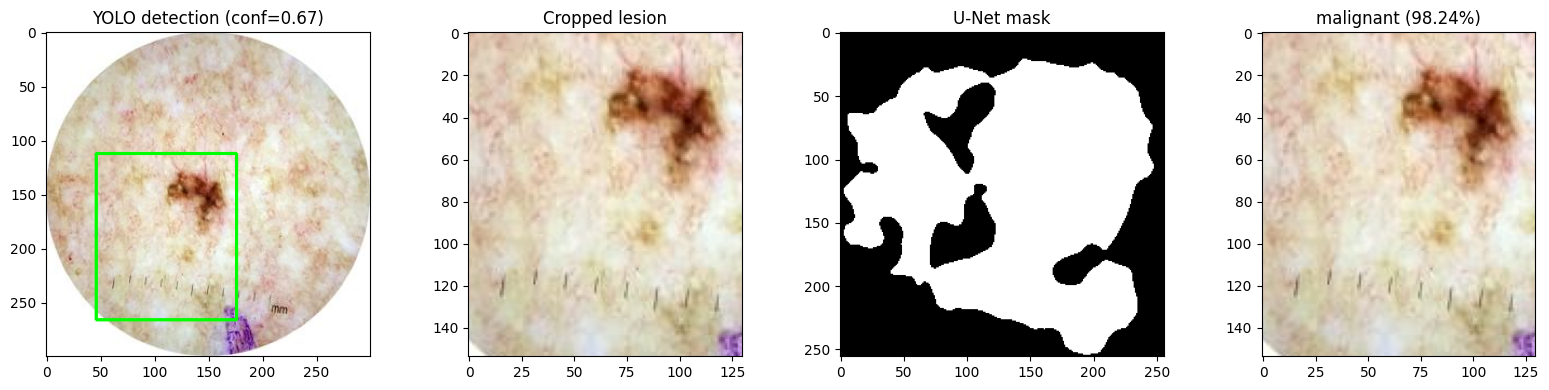

melanoma_10109.jpg: malignant (98.24%)


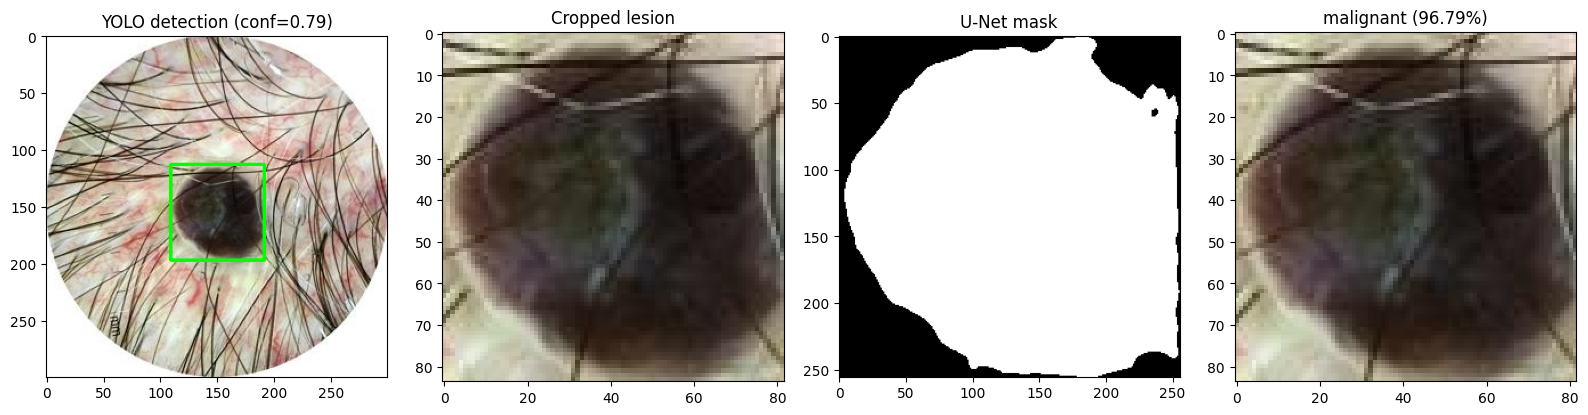

melanoma_10110.jpg: malignant (96.79%)


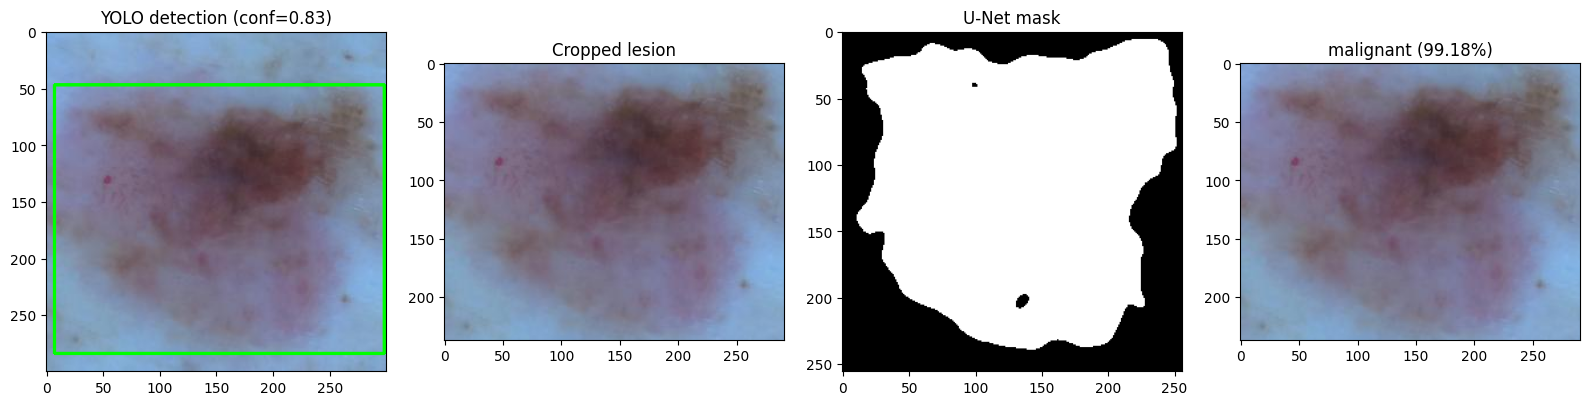

melanoma_10111.jpg: malignant (99.18%)


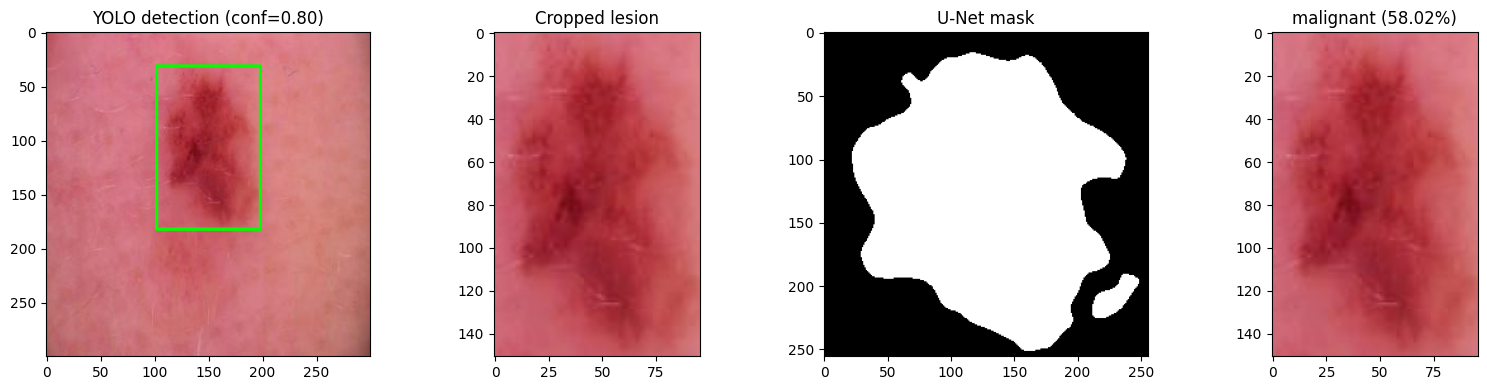

melanoma_10112.jpg: malignant (58.02%)


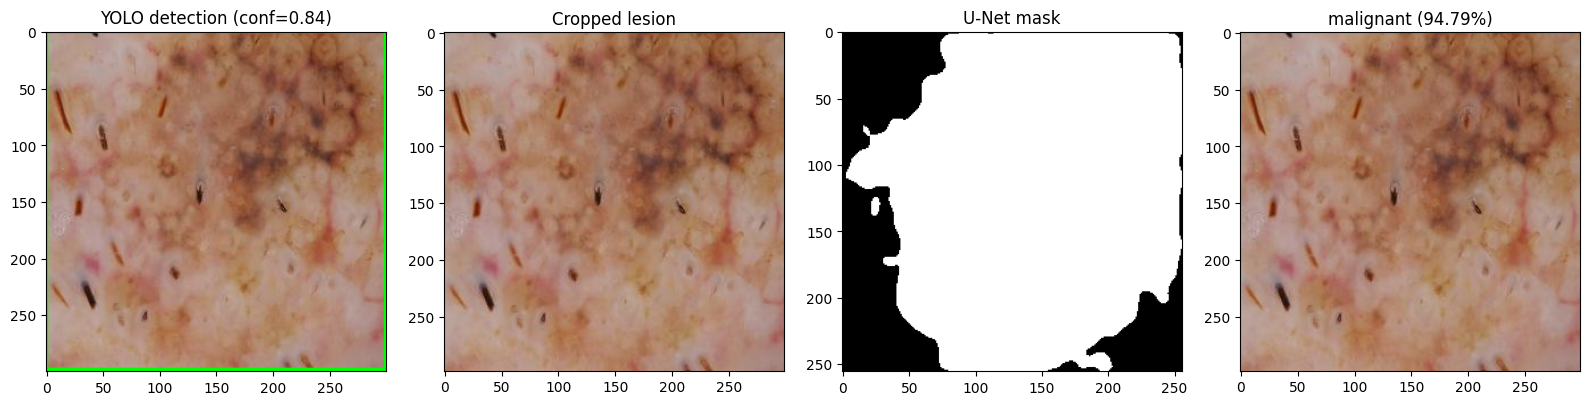

melanoma_10113.jpg: malignant (94.79%)


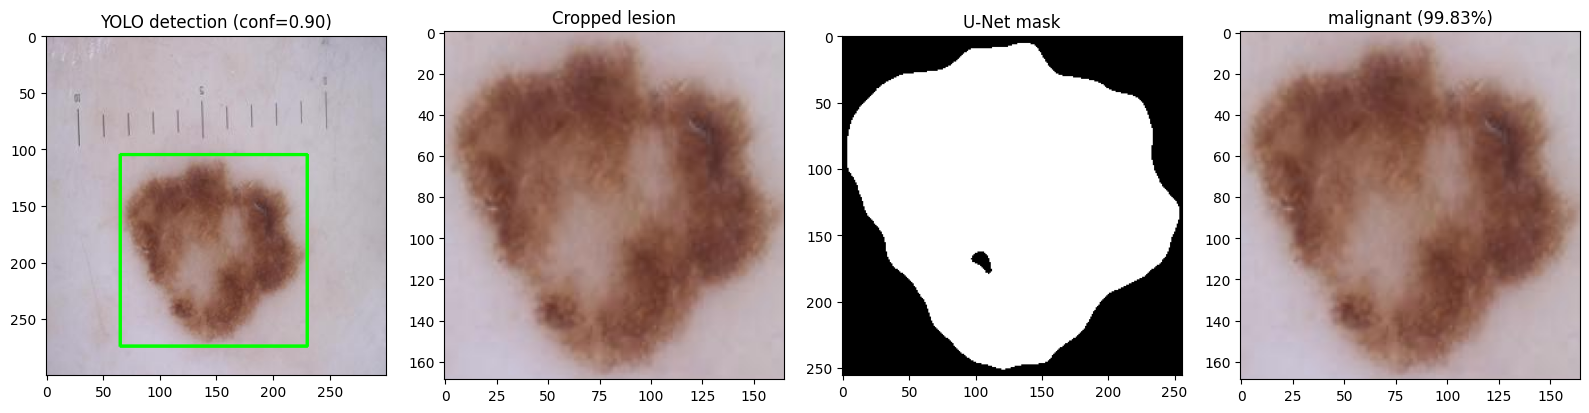

melanoma_10114.jpg: malignant (99.83%)

Gotowe -- przetworzono 10 zdjec.


In [10]:
# Odpal run_pipeline() dla WSZYSTKICH zdjec w folderze 

test_folder = r'../test_images'

image_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f'Znaleziono {len(image_files)} zdjec w folderze.\n')

plt.ioff()  # wylacz automatyczne wyswietlanie wykresow, zeby nie zaśmiecac notebooka
results = []

try:
    for img_name in image_files:
        img_path = os.path.join(test_folder, img_name)
        label, confidence = run_pipeline(img_path)
        plt.close('all')  # zamknij figure z run_pipeline, zeby nie zuzywac pamieci

        if label is not None:
            print(f'{img_name}: {label} ({confidence:.2%})')
            results.append({'file': img_name, 'pred': label, 'confidence': confidence})
        else:
            print(f'{img_name}: Brak detekcji ze strony YOLO.')
            results.append({'file': img_name, 'pred': None, 'confidence': None})
finally:
    plt.ion()  # przywroc normalny tryb wyswietlania

print(f'\nGotowe -- przetworzono {len(results)} zdjec.')

In [11]:
from collections import Counter
counts = Counter(r['pred'] for r in results)
print(f'\nPodsumowanie: {dict(counts)}')


Podsumowanie: {'benign': 1, None: 1, 'malignant': 8}
